# Self-Similarity Analysis

In this notebook we reproduce the first experiment from the paper.

The goal is to measure how similar a word's contextualized representations remain across different contexts.

For a target word, we collect multiple sentences containing that word, extract its embedding from every BERT layer, and compute pairwise cosine similarities.

If similarity decreases in higher layers, this indicates that contextual information increasingly influences the representation.

cell 1 - imports

In [7]:
import sys
import numpy as np
import itertools
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

cell 2 - create contexts

In [30]:
sentences = [
   "I ate an apple for breakfast.",
    "The apple was very sweet.",
    "apple released a new iPhone.",
    "apple announced new AI features.",
    "The company apple is investing heavily in chips."
]

cell 3 - extract embeddings

In [41]:
sys.path.append("..") # add the parent directory to the system path to access the src folder
from src.embeddings import get_word_embedding

all_embeddings = []

for sentence in sentences:
    
    embeddings = get_word_embedding(
        sentence,
        "apple"
    )
    
    all_embeddings.append(embeddings) # store the embeddings in the list 

cell 4 - check everything

In [42]:
print(len(all_embeddings)) # how many contexts
print(len(all_embeddings[0])) # embeddings of first sentence
print(all_embeddings[0][0].shape) # shape of the first layerof the first sentence

5
13
(768,)


cell 5 - function to compute average similarity

Suppose we have: bank_context1 bank_context2 bank_context3

It computes: sim(1,2) sim(1,3) sim(2,3)

  cosine similarity=v1​⋅v2/​​∥v1​∥∥v2​∥

and averages them.

In [43]:
def average_similarity(vectors):

    similarities = []

    for v1,v2 in itertools.combinations(vectors,2): # generate all unique pairs of vectors

        sim = cosine_similarity(
            [v1]
            ,[v2]
            )[0][0] # cosine_similarity returns a 2D array, we take the first element which is the similarity score
        similarities.append(sim)
    print("Number of similarities:",
      len(similarities))
    return np.mean(similarities)

cell 6- computre similarity layer by layer

In [44]:
layer_scores = []

for layer_idx in range(len(all_embeddings[0])): # iterate over each layer

    layer_vectors = []

    for sentence_idx in range(len(all_embeddings)): # iterate over each sentence

        layer_vectors.append(all_embeddings[sentence_idx][layer_idx]) # get the vector for the current layer and sentence

    score= average_similarity(layer_vectors) # compute the average similarity for the current

    layer_scores.append(score) # store the score for the current layer

Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10


cell 9 - print results

Layer 0 similarity is not always equal to 1 because BERT's input representation includes positional embeddings in addition to token embeddings. Consequently, occurrences of the same word at different positions can have different initial representations.

In [45]:
for layer, score in enumerate(
    layer_scores
):
    print(
        f"Layer {layer}: {score:.4f}"
    )

Layer 0: 0.9535
Layer 1: 0.8676
Layer 2: 0.8040
Layer 3: 0.7567
Layer 4: 0.7084
Layer 5: 0.6891
Layer 6: 0.6679
Layer 7: 0.6725
Layer 8: 0.6495
Layer 9: 0.6116
Layer 10: 0.6069
Layer 11: 0.6132
Layer 12: 0.4733


cell 10 - Plot

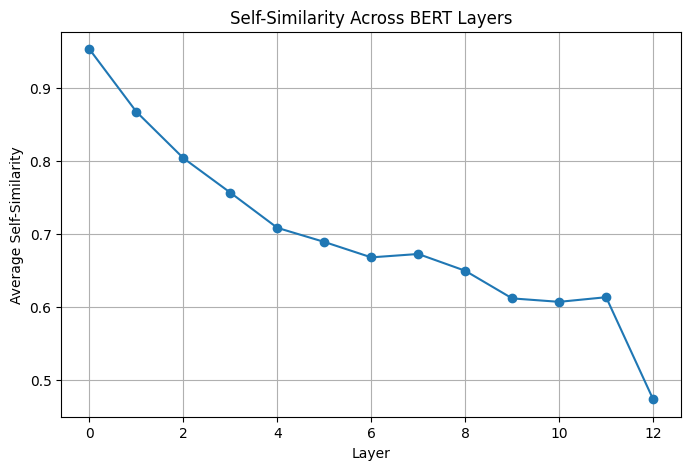

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    range(13),
    layer_scores,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel(
    "Average Self-Similarity"
)

plt.title(
    "Self-Similarity Across BERT Layers"
)

plt.grid(True)

plt.show()

The biggest drop occurs very early:

0.97
↓
0.86
↓
0.83
↓
0.79

within the first few layers.

This suggests that BERT starts contextualizing the word quite early.

A research question that naturally arises is:

At which layer is most of the contextualization completed?

2b — Polysemy Analysis

# Polysemy Experiment

In the previous experiment, all occurrences of the word "bank" referred to a financial institution.

In this notebook, we investigate whether contextualization increases when a word is used with multiple meanings.

We use occurrences of the word "bank" in both financial and river-related contexts and measure self-similarity across BERT layers.

Hypothesis:
Representations of polysemous words should exhibit lower self-similarity in higher layers because BERT must distinguish between different senses of the same word.

cell 1 - reusable function

In [59]:
def run_self_similarity_experiment(
        sentences,
        target_word
):

    all_embeddings = []

    for sentence in sentences:

        embeddings = get_word_embedding(
            sentence,
            target_word
        )

        all_embeddings.append(embeddings)

    layer_scores = []

    num_layers = len(all_embeddings[0])

    for layer_idx in range(num_layers):

        layer_vectors = []

        for sentence_idx in range(
            len(all_embeddings)
        ):

            layer_vectors.append(
                all_embeddings[sentence_idx][layer_idx]
            )

        score = average_similarity(
            layer_vectors
        )

        layer_scores.append(score)

    return layer_scores

cell 2 - datasets creation

In [60]:
financial_bank = [
    "The bank approved the loan.",
    "The bank lowered interest rates.",
    "The bank opened a new branch.",
    "The bank rejected the application.",
    "The bank increased mortgage offerings."
]

mixed_bank = [
    "The bank approved the loan.",
    "The bank lowered interest rates.",
    "The fisherman sat on the bank of the river.",
    "The flood damaged the bank.",
    "Children played near the river bank."
]

cell 3 - running experiments

In [61]:
financial_scores =(
    run_self_similarity_experiment(
    financial_bank,
    "bank"
)
)

mixed_scores =(
    run_self_similarity_experiment(
        mixed_bank,
        "bank"
    )
)

Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10
Number of similarities: 10


cell 4 - compare them

<class 'list'>
[np.float32(0.9999999), np.float32(0.9167665), np.float32(0.91911906), np.float32(0.9130229), np.float32(0.9031223), np.float32(0.875127), np.float32(0.87684315), np.float32(0.8844476), np.float32(0.8727897), np.float32(0.8624983), np.float32(0.87115765), np.float32(0.87316626), np.float32(0.84587383)]
<class 'list'>
[np.float32(0.95866144), np.float32(0.8259016), np.float32(0.7829422), np.float32(0.7155715), np.float32(0.67384535), np.float32(0.6505682), np.float32(0.6414388), np.float32(0.6326377), np.float32(0.6126807), np.float32(0.60466635), np.float32(0.6238759), np.float32(0.6520116), np.float32(0.60805696)]


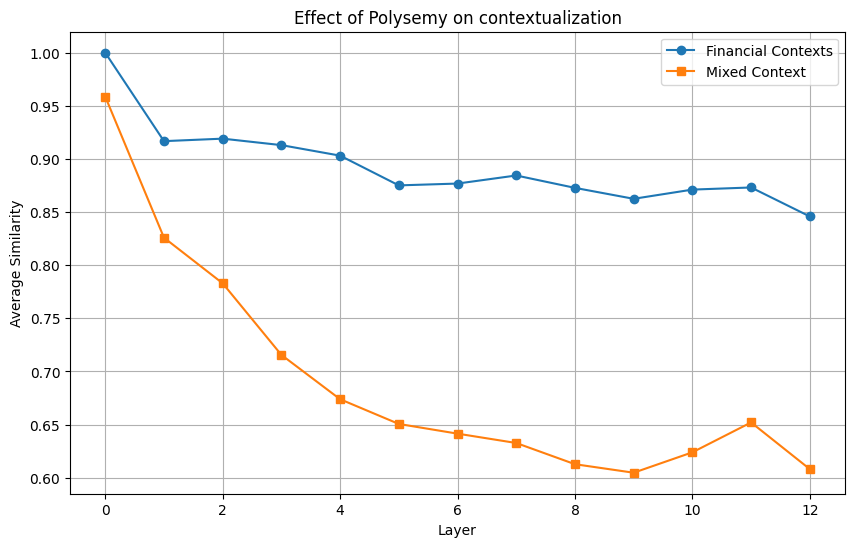

In [ ]:

plt.figure(figsize=(10,6))

plt.plot(
    financial_scores,
    marker="o",
    label="Financial Contexts"

)

plt.plot(
    mixed_scores,
    marker="s",
    label="Mixed Context"
)

plt.xlabel("Layer")
plt.ylabel("Average Similarity")
plt.title("Effect of Polysemy on contextualization")
plt.legend()
plt.grid(True)
plt.show()

## Discussion

The polysemous version of "bank" exhibits substantially lower self-similarity than the single-sense version.

While both experiments start with highly similar representations in early layers, the gap widens in deeper layers.

This indicates that BERT progressively incorporates contextual information and differentiates between semantic senses of the same word.

The results support the hypothesis that contextualization is stronger for ambiguous words than for words used consistently with a single meaning.